# Modelo Preditivo de Risco Futuro — TerraJourney

O objetivo deste notebook é prever se um aluno apresentará **risco de defasagem no período seguinte**, utilizando apenas informações disponíveis no ano atual. O target é construído exclusivamente a partir de casos em que o `IAN` do ano seguinte é realmente conhecido.


## 1. Bibliotecas e identidade visual

As bibliotecas e a paleta de cores do projeto são centralizadas nesta seção.


In [1]:
import numpy as np
import json
import joblib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

cores_projeto = ['#2A5C43', '#C4A052', '#8BA891']

COR_PRIMARIA = '#2A5C43'
COR_DESTAQUE = '#C4A052'
COR_SECUNDARIA = '#8BA891'
COR_FUNDO = '#F3F3EC'


## 2. Carregamento da base

A base consolidada é ordenada por `RA` e `Ano_Referencia`, permitindo identificar corretamente o registro do mesmo aluno no período seguinte.


In [2]:
github = (
    'https://raw.githubusercontent.com/andersonserrico/'
    'Datathon_TerraJourney_Grupo48/main/dados/'
    'PEDE_Dados_Unificados.csv'
)

df = pd.read_csv(
    github,
    sep=',',
    encoding='utf-8-sig'
)

df = (
    df
    .sort_values(['RA', 'Ano_Referencia'])
    .reset_index(drop=True)
)

print('Dimensão da base:', df.shape)


Dimensão da base: (3030, 36)


## 3. Construção do target `RISCO_FUTURO`

O `IAN_Futuro` é obtido somente quando existe um registro do mesmo aluno no **ano imediatamente seguinte**. Assim, não são criados targets artificiais para alunos sem futuro observado.

A regra utilizada é:

- `RISCO_FUTURO = 1` quando `IAN_Futuro < 10`;
- `RISCO_FUTURO = 0` quando `IAN_Futuro = 10`.


In [3]:
df_modelo = df.copy()

df_modelo['Ano_Futuro'] = (
    df_modelo
    .groupby('RA')['Ano_Referencia']
    .shift(-1)
)

df_modelo['IAN_Futuro'] = (
    df_modelo
    .groupby('RA')['IAN']
    .shift(-1)
)

ano_consecutivo = (
    df_modelo['Ano_Futuro']
    == df_modelo['Ano_Referencia'] + 1
)

df_modelo.loc[
    ~ano_consecutivo,
    ['Ano_Futuro', 'IAN_Futuro']
] = np.nan

df_modelo['RISCO_FUTURO'] = np.where(
    df_modelo['IAN_Futuro'].notna(),
    (df_modelo['IAN_Futuro'] < 10).astype(int),
    np.nan
)

registros_futuro = df_modelo['RISCO_FUTURO'].notna().sum()

print('Registros totais:', len(df_modelo))
print('Registros com futuro conhecido:', registros_futuro)
print(
    'Percentual com futuro conhecido:',
    round(registros_futuro / len(df_modelo) * 100, 2),
    '%'
)


Registros totais: 3030
Registros com futuro conhecido: 1365
Percentual com futuro conhecido: 45.05 %


## 4. Features finais

Os experimentos mostraram que `Genero`, `Instituicao_Ensino` e `INDE_Sem_IAN` não produziram ganho consistente. O modelo final utiliza o `IAN`, o `INDE` observado no ano atual, os indicadores individuais e a `Idade`.


In [4]:
features = [
    'IAN',
    'INDE',
    'IDA',
    'IEG',
    'IPS',
    'IPP',
    'IAA',
    'IPV',
    'Idade'
]

print('Features do modelo:')
print(features)


Features do modelo:
['IAN', 'INDE', 'IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'Idade']


## 5. Base de modelagem

Somente registros com target conhecido e com todas as features finais disponíveis entram no treinamento. Após essa seleção, a distribuição do target permanece praticamente equilibrada.


In [5]:
colunas_modelo = [
    'RA',
    'Ano_Referencia',
    'Ano_Futuro',
    'IAN_Futuro',
    'RISCO_FUTURO'
] + features

ml_base = (
    df_modelo
    .loc[
        df_modelo['RISCO_FUTURO'].notna(),
        colunas_modelo
    ]
    .dropna(subset=features)
    .copy()
)

ml_base['RISCO_FUTURO'] = (
    ml_base['RISCO_FUTURO']
    .astype(int)
)

print('Dimensão da base para ML:', ml_base.shape)

print()
print('Distribuição do target:')
print(ml_base['RISCO_FUTURO'].value_counts())

print()
print('Percentual:')
print(
    ml_base['RISCO_FUTURO']
    .value_counts(normalize=True)
    .round(3)
)


Dimensão da base para ML: (1290, 14)

Distribuição do target:
RISCO_FUTURO
1    671
0    619
Name: count, dtype: int64

Percentual:
RISCO_FUTURO
1    0.52
0    0.48
Name: proportion, dtype: float64


## 6. Correlação com o risco futuro

A matriz permite observar associações lineares entre o target e as variáveis atuais. Ela deve ser interpretada em conjunto com a importância do modelo, pois o Gradient Boosting também captura relações não lineares e interações.


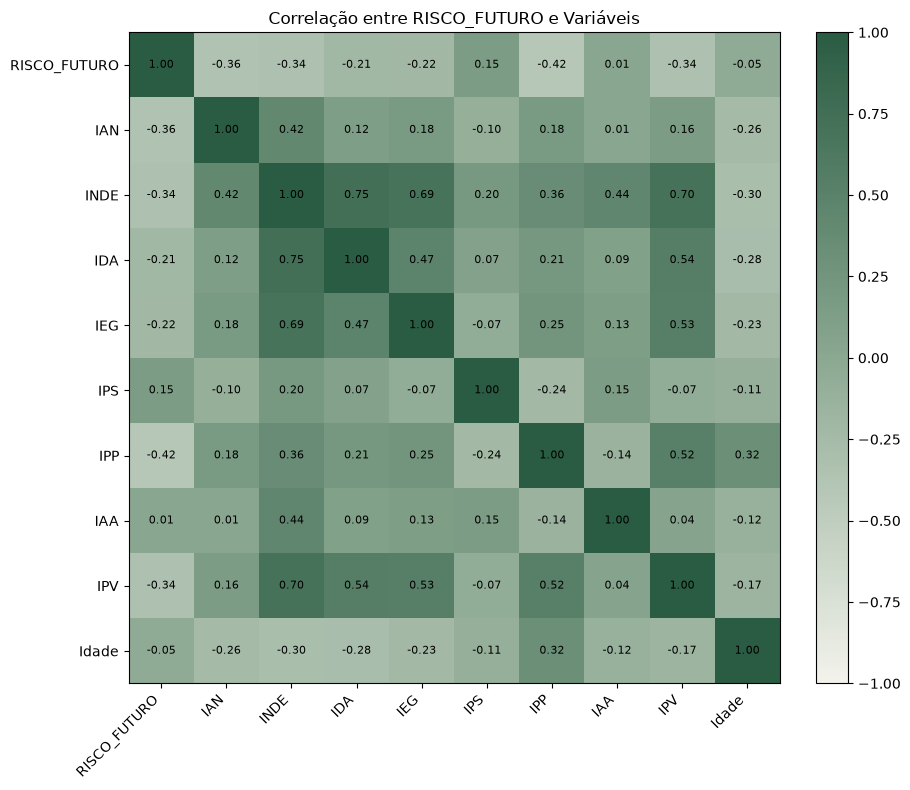

In [6]:
corr_vars = [
    'RISCO_FUTURO',
    'IAN',
    'INDE',
    'IDA',
    'IEG',
    'IPS',
    'IPP',
    'IAA',
    'IPV',
    'Idade'
]

corr = ml_base[corr_vars].corr()

cmap_correlacao = LinearSegmentedColormap.from_list(
    'correlacao_projeto',
    [COR_FUNDO, COR_SECUNDARIA, COR_PRIMARIA]
)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr.values,
    cmap=cmap_correlacao,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f'{corr.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=8
        )

ax.set_title('Correlação entre RISCO_FUTURO e Variáveis')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 7. Separação entre treino e teste por aluno

A divisão é realizada por `RA`, impedindo que diferentes anos do mesmo aluno apareçam simultaneamente no treino e no teste. O `GroupShuffleSplit` mantém aproximadamente 70% dos alunos para treinamento e 30% para avaliação final.


In [7]:
X = ml_base[features].copy()
y = ml_base['RISCO_FUTURO'].copy()
groups = ml_base['RA'].copy()

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print('RAs no treino:', groups_train.nunique())
print('RAs no teste :', groups_test.nunique())
print(
    'Interseção de RAs:',
    len(set(groups_train) & set(groups_test))
)

print()
print('Distribuição Treino:')
print(
    y_train
    .value_counts(normalize=True)
    .round(3)
)

print()
print('Distribuição Teste:')
print(
    y_test
    .value_counts(normalize=True)
    .round(3)
)


RAs no treino: 592
RAs no teste : 255
Interseção de RAs: 0

Distribuição Treino:
RISCO_FUTURO
1    0.521
0    0.479
Name: proportion, dtype: float64

Distribuição Teste:
RISCO_FUTURO
1    0.518
0    0.482
Name: proportion, dtype: float64


## 8. Pré-processamento

As features finais são numéricas. O `RobustScaler` é aplicado dentro do pipeline, preservando o processamento correto dentro de cada etapa de validação.


In [8]:
colunas_numericas = features.copy()

preprocessador = ColumnTransformer([
    (
        'num',
        RobustScaler(),
        colunas_numericas
    )
])

print('Colunas numéricas:', colunas_numericas)


Colunas numéricas: ['IAN', 'INDE', 'IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'Idade']


## 9. Treinamento e Cross-Validation

Random Forest e Gradient Boosting são comparados com `StratifiedGroupKFold`. A estratégia tenta preservar a proporção do target em cada fold e, ao mesmo tempo, impede que o mesmo `RA` apareça no treino e na validação do mesmo fold.


In [9]:
modelo_rf = Pipeline([
    (
        'preprocessor',
        preprocessador
    ),
    (
        'classifier',
        RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        )
    )
])

modelo_gb = Pipeline([
    (
        'preprocessor',
        preprocessador
    ),
    (
        'classifier',
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=10,
            random_state=42
        )
    )
])

modelos_cv = {
    'Random Forest': modelo_rf,
    'Gradient Boosting - leaf 10': modelo_gb
}

metricas = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_group = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = []

for nome, modelo in modelos_cv.items():

    cv = cross_validate(
        estimator=modelo,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_group,
        scoring=metricas,
        n_jobs=-1
    )

    resultados_cv.append({
        'Modelo': nome,
        'Accuracy': cv['test_accuracy'].mean(),
        'Accuracy STD': cv['test_accuracy'].std(),
        'Precision': cv['test_precision'].mean(),
        'Precision STD': cv['test_precision'].std(),
        'Recall': cv['test_recall'].mean(),
        'Recall STD': cv['test_recall'].std(),
        'F1 Score': cv['test_f1'].mean(),
        'F1 Score STD': cv['test_f1'].std(),
        'ROC AUC': cv['test_roc_auc'].mean(),
        'ROC AUC STD': cv['test_roc_auc'].std()
    })

df_cv = (
    pd.DataFrame(resultados_cv)
    .sort_values(
        'ROC AUC',
        ascending=False
    )
    .reset_index(drop=True)
)

display(df_cv.round(4))


,Modelo,Accuracy,Accuracy STD,Precision,Precision STD,Recall,Recall STD,F1 Score,F1 Score STD,ROC AUC,ROC AUC STD
0,Gradient Boosting - leaf 10,0.7616,0.0149,0.757,0.0182,0.8000,0.0217,0.7776,0.0130,0.8512,0.023
1,Random Forest,0.7494,0.0275,0.752,0.0314,0.7766,0.0415,0.7634,0.0271,0.8412,0.018


## 10. Avaliação final no conjunto de teste

O modelo com maior ROC AUC médio na Cross-Validation é treinado com todo o conjunto de treino e avaliado uma única vez nos alunos reservados para teste.


In [10]:
nome_melhor_modelo = df_cv.loc[0, 'Modelo']
melhor_modelo = modelos_cv[nome_melhor_modelo]

melhor_modelo.fit(
    X_train,
    y_train
)

pred = melhor_modelo.predict(
    X_test
)

probabilidades = melhor_modelo.predict_proba(
    X_test
)[:, 1]

print('Melhor modelo:', nome_melhor_modelo)
print(
    'Accuracy :',
    round(accuracy_score(y_test, pred), 4)
)
print(
    'Precision:',
    round(precision_score(y_test, pred), 4)
)
print(
    'Recall   :',
    round(recall_score(y_test, pred), 4)
)
print(
    'F1 Score :',
    round(f1_score(y_test, pred), 4)
)
print(
    'ROC AUC  :',
    round(roc_auc_score(y_test, probabilidades), 4)
)


Melhor modelo: Gradient Boosting - leaf 10
Accuracy : 0.768
Precision: 0.7656
Recall   : 0.796
F1 Score : 0.7805
ROC AUC  : 0.8433


### 10.1 Justificativa IAN

Foi realizado teste sem o índice IAN atual para verificar a real dependência do modelo com o Indicador.  
No teste, mesmo após a remoção do IAN atual, o modelo manteve capacidade preditiva satisfatória (ROC AUC = 0,822), indicando que os demais indicadores já contêm informações suficientes para antecipar situações de defasagem futura.  
O IPP (Índice de Processos Pedagógicos) foi a variável mais importante, respondendo por aproximadamente 34% da importância total do modelo, seguido pelo INDE (20%) e pela idade do estudante (17%).  
Esse resultado sugere que fatores pedagógicos e o desenvolvimento educacional global possuem maior capacidade de antecipar a entrada em defasagem do que a condição atual de defasagem isoladamente.  
Com isso, optou-se por mantê-lo no modelo.

## 11. Matriz de confusão

Os falsos negativos representam alunos que efetivamente entraram em risco no período seguinte, mas não foram antecipados pelo modelo.


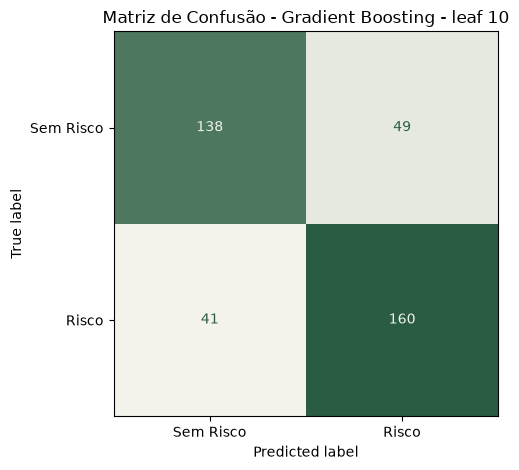

                    PREVISTO
              Sem Risco    Risco
REAL
Sem Risco        138      49
Risco            41       160


In [11]:
cm = confusion_matrix(
    y_test,
    pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Sem Risco',
        'Risco'
    ]
)

disp.plot(
    values_format='d',
    cmap=LinearSegmentedColormap.from_list(
        'matriz_projeto',
        [
            COR_FUNDO,
            COR_SECUNDARIA,
            COR_PRIMARIA
        ]
    ),
    colorbar=False
)

plt.title(
    f'Matriz de Confusão - {nome_melhor_modelo}'
)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print('                    PREVISTO')
print('              Sem Risco    Risco')
print('REAL')
print(f'Sem Risco        {tn:<8} {fp}')
print(f'Risco            {fn:<8} {tp}')


## 12. Importância das variáveis e perfil dos grupos

A importância indica quanto cada feature contribuiu para as decisões do modelo. A comparação das médias entre as classes complementa essa análise, mostrando como os perfis atuais diferem entre alunos que apresentaram ou não risco no período seguinte.


In [12]:
preprocessor = (
    melhor_modelo
    .named_steps['preprocessor']
)

classificador = (
    melhor_modelo
    .named_steps['classifier']
)

nomes_features = (
    preprocessor
    .get_feature_names_out()
)

importancias = (
    classificador
    .feature_importances_
)

fi = (
    pd.DataFrame({
        'Variavel': nomes_features,
        'Importancia': importancias
    })
    .sort_values(
        'Importancia',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    fi.round(4)
)

df_analise = X_test.copy()
df_analise['RISCO_FUTURO'] = y_test.values

display(
    df_analise
    .groupby('RISCO_FUTURO')[features]
    .mean()
    .round(2)
)


,Variavel,Importancia
0,num__IPP,0.3135
1,num__Idade,0.2046
2,num__IAN,0.1665
3,num__INDE,0.1019
4,num__IPV,0.0777
5,num__IPS,0.0436
6,num__IDA,0.0418
7,num__IEG,0.0315
8,num__IAA,0.0189


,IAN,INDE,IDA,IEG,IPS,IPP,IAA,IPV,Idade
RISCO_FUTURO,,,,,,,,,
0,7.65,7.70,6.98,8.93,5.63,7.59,7.94,8.20,11.93
1,5.98,7.07,6.34,8.34,6.30,6.45,7.70,7.43,11.30


## 13. Análise específica da Idade

A `Idade` apresentou alta importância no Gradient Boosting, apesar de correlação linear relativamente baixa com o target. A análise por faixa etária mostrou que essa relação é não linear: o risco é mais elevado entre 7–9 anos, cai entre 10–13 e volta a crescer entre 14–17. A faixa 18+ possui poucos registros e deve ser interpretada com cautela.


In [13]:
analise_idade = (
    ml_base
    .groupby('Idade')
    .agg(
        Quantidade=('RISCO_FUTURO', 'size'),
        Sem_Risco=(
            'RISCO_FUTURO',
            lambda x: (x == 0).sum()
        ),
        Risco=(
            'RISCO_FUTURO',
            lambda x: (x == 1).sum()
        ),
        Taxa_Risco=(
            'RISCO_FUTURO',
            'mean'
        )
    )
    .reset_index()
)

analise_idade['Taxa_Risco'] = (
    analise_idade['Taxa_Risco']
    * 100
).round(2)

display(
    analise_idade
)

ml_base['Faixa_Idade'] = pd.cut(
    ml_base['Idade'],
    bins=[
        6,
        9,
        13,
        17,
        float('inf')
    ],
    labels=[
        '7-9',
        '10-13',
        '14-17',
        '18+'
    ]
)

analise_faixa = (
    ml_base
    .groupby(
        'Faixa_Idade',
        observed=True
    )
    .agg(
        Quantidade=(
            'RISCO_FUTURO',
            'size'
        ),
        Risco=(
            'RISCO_FUTURO',
            'sum'
        ),
        Taxa_Risco=(
            'RISCO_FUTURO',
            'mean'
        )
    )
    .reset_index()
)

analise_faixa['Taxa_Risco'] = (
    analise_faixa['Taxa_Risco']
    * 100
).round(2)

display(
    analise_faixa
)


,Idade,Quantidade,Sem_Risco,Risco,Taxa_Risco
0,7,35,14,21,60.00
1,8,103,46,57,55.34
2,9,161,40,121,75.16
3,10,182,100,82,45.05
4,11,183,86,97,53.01
5,12,152,104,48,31.58
6,13,145,93,52,35.86
7,14,122,57,65,53.28
8,15,78,24,54,69.23
9,16,65,14,51,78.46


,Faixa_Idade,Quantidade,Risco,Taxa_Risco
0,7-9,299,199,66.56
1,10-13,662,279,42.15
2,14-17,314,191,60.83
3,18+,15,2,13.33


## 14. Função de previsão

A função abaixo recebe os indicadores atuais de um aluno e retorna a probabilidade estimada de risco no período seguinte.


In [14]:
def prever_risco_futuro(
    ian,
    inde,
    ida,
    ieg,
    ips,
    ipp,
    iaa,
    ipv,
    idade
):

    novo_aluno = pd.DataFrame({
        'IAN': [ian],
        'INDE': [inde],
        'IDA': [ida],
        'IEG': [ieg],
        'IPS': [ips],
        'IPP': [ipp],
        'IAA': [iaa],
        'IPV': [ipv],
        'Idade': [idade]
    })

    prob = melhor_modelo.predict_proba(
        novo_aluno[features]
    )[0, 1]

    classe = int(
        melhor_modelo.predict(
            novo_aluno[features]
        )[0]
    )

    classificacao = (
        'Risco'
        if classe == 1
        else 'Sem Risco'
    )

    print(
        f'Probabilidade de risco futuro: '
        f'{prob:.2%}'
    )

    print(
        f'Classificação: '
        f'{classificacao}'
    )

    return prob


In [15]:
prever_risco_futuro(
    ian=10.0,
    inde=8.0,
    ida=8.0,
    ieg=8.0,
    ips=7.0,
    ipp=7.5,
    iaa=8.0,
    ipv=8.0,
    idade=12
)


Probabilidade de risco futuro: 3.77%
Classificação: Sem Risco


np.float64(0.03774117809677047)

## 15. Resumo do modelo

O objetivo do modelo foi identificar, de forma antecipada, alunos com maior probabilidade de entrar em situação de defasagem educacional. Para isso, foi criado o target RISCO_FUTURO, definido a partir do desempenho efetivamente observado no ano seguinte. Foram classificados como em risco os alunos cujo IAN_Futuro foi inferior a 10, indicando algum nível de defasagem em relação à fase considerada ideal para sua idade. O possível uso de um targets diferentes como IAN_Futuro < IAN_Atual não contemplaria os casos de alunos com IAN no patamar mais baixo, pois eles estariam sem risco de diminuição. 

Para evitar vazamento de informação e garantir uma avaliação mais realista da capacidade preditiva, a separação entre treino e teste foi realizada por RA (identificador do aluno), assegurando que um mesmo estudante não estivesse presente simultaneamente nos dois conjuntos. Além disso, a validação cruzada utilizou o método StratifiedGroupKFold, preservando tanto o balanceamento das classes quanto a independência entre os grupos de alunos.

Foram avaliados diferentes algoritmos de Machine Learning, sendo o Gradient Boosting o modelo que apresentou o melhor equilíbrio entre capacidade discriminatória (ROC AUC), identificação de alunos em risco (Recall) e equilíbrio geral entre precisão e sensibilidade (F1-Score). O desempenho observado no conjunto de teste foi consistente com os resultados da validação cruzada, indicando boa capacidade de generalização e reduzindo evidências de sobreajuste (overfitting).

A análise das importâncias das variáveis mostrou que os fatores mais relevantes para a previsão do risco futuro foram IPP, Idade, IAN atual e INDE. O destaque do IPP sugere que aspectos relacionados ao desenvolvimento pedagógico do estudante possuem forte relação com a ocorrência de defasagem futura. Já a relevância do IAN atual indica que a situação educacional presente do aluno continua sendo um importante sinalizador de risco, embora não seja suficiente para explicar o fenômeno isoladamente.

A variável Idade apresentou comportamento diferente. Embora sua correlação linear com o target não tenha sido das mais elevadas, o modelo identificou padrões não lineares importantes. Observou-se que a probabilidade de risco é mais elevada entre estudantes de 7 a 9 anos, reduz-se nas faixas intermediárias e volta a aumentar entre aproximadamente 14 e 17 anos. Esse comportamento ajuda a explicar sua elevada importância no Gradient Boosting, algoritmo capaz de capturar relações complexas que não seriam identificadas por análises puramente lineares.

De outro modo, variáveis como Gênero e Instituição de Ensino apresentaram baixa importância preditiva. Embora algumas análises descritivas tenham mostrado diferenças entre grupos, essas variáveis adicionaram pouca informação ao modelo após o controle pelos indicadores pedagógicos e educacionais. Isso sugere que eventuais diferenças observadas entre os grupos são explicadas principalmente pelos próprios indicadores de desempenho e desenvolvimento dos estudantes.

Por fim, os resultados indicam que o risco de defasagem futura pode ser antecipado com boa precisão a partir de informações dos indicadores dos aluno, permitindo identificar perfis mais vulneráveis e subsidiar ações preventivas antes que a defasagem aconteça. 

# 16. Artefato único para uso no Streamlit

O modelo é exportado em um único arquivo `.pkl`. Esse artefato contém o pipeline treinado e também os dados necessários para reconstruir os gráficos de avaliação no Streamlit, sem executar novamente treinamento, Cross-Validation ou `predict_proba` na base de teste.

Estrutura do artefato:

- `modelo`: pipeline completo treinado;
- `features`: ordem das features esperadas na predição;
- `avaliacao`: probabilidades, predições, classes reais e limiar de classificação;
- `importancia_features`: DataFrame utilizado no gráfico de importância;
- `analise_idade`: DataFrame utilizado no gráfico de idade e taxa de risco.


In [16]:
# =========================================================
# Construção do artefato único
# =========================================================

artefato_modelo = {
    'modelo': melhor_modelo,

    'features': features,

    'avaliacao': {
        'probabilidades_teste': probabilidades,
        'predicoes_teste': pred,
        'y_test': y_test.to_numpy(),
        'limiar_classificacao': 0.50
    },

    'importancia_features': (
        fi
        .assign(
            Variavel=lambda df: (
                df['Variavel']
                .str.replace(
                    'num__',
                    '',
                    regex=False
                )
            ),
            Importancia_Percentual=lambda df: (
                df['Importancia'] * 100
            )
        )
        .copy()
    ),

    'analise_idade': (
        analise_idade
        .copy()
    ),

    # =========================================================
    # Análise por Gênero
    # =========================================================

    'analise_genero': (
        pd.crosstab(
            df_modelo['Genero'],
            df_modelo['RISCO_FUTURO'],
            normalize='index'
        ).round(4)
    ),


    # =========================================================
    # Análise por Instituição
    # =========================================================

    'analise_instituicao': (
        pd.crosstab(
            df_modelo['Instituicao_Ensino'],
            df_modelo['RISCO_FUTURO'],
            normalize='index'
        ).round(4)
    )
}



# =========================================================
# Salvando o artefato
# =========================================================

caminho_modelo = '../modelo/modelo_risco.pkl'

joblib.dump(
    artefato_modelo,
    caminho_modelo
)

print(f'Modelo salvo em: {caminho_modelo}')
print(
    artefato_modelo.keys()
)


Modelo salvo em: ../modelo/modelo_risco.pkl
dict_keys(['modelo', 'features', 'avaliacao', 'importancia_features', 'analise_idade', 'analise_genero', 'analise_instituicao'])


## Exemplo de carregamento no Streamlit

O Streamlit pode carregar o artefato uma única vez e reutilizar tanto o pipeline quanto os DataFrames necessários para os gráficos.


In [17]:
# Exemplo de uso no Streamlit
#
# import joblib
# import numpy as np
# import pandas as pd
#
# artefato_modelo = joblib.load(
#     'modelo_risco_futuro.pkl'
# )
#
# modelo = artefato_modelo['modelo']
# features = artefato_modelo['features']
#
#
# # ---------------------------------------------------------
# # Gráfico 1 — Importância das variáveis
# # ---------------------------------------------------------
#
# df_importancia = (
#     artefato_modelo[
#         'importancia_features'
#     ]
#     .copy()
# )
#
#
# # ---------------------------------------------------------
# # Gráfico 2 — Distribuição das probabilidades
# # ---------------------------------------------------------
#
# probabilidades = np.array(
#     artefato_modelo[
#         'avaliacao'
#     ][
#         'probabilidades_teste'
#     ]
# ) * 100
#
# limiar = (
#     artefato_modelo[
#         'avaliacao'
#     ][
#         'limiar_classificacao'
#     ]
#     * 100
# )
#
# df_probabilidades = pd.DataFrame(
#     {
#         'Probabilidade': probabilidades
#     }
# )
#
#
# # ---------------------------------------------------------
# # Gráfico 3 — Idade e taxa de risco
# # ---------------------------------------------------------
#
# df_idade = (
#     artefato_modelo[
#         'analise_idade'
#     ]
#     .copy()
# )


# 17. Gráficos finais para análise

Os três gráficos abaixo sintetizam a interpretação do modelo: importância das features, distribuição dos scores de risco e comportamento do risco por idade.


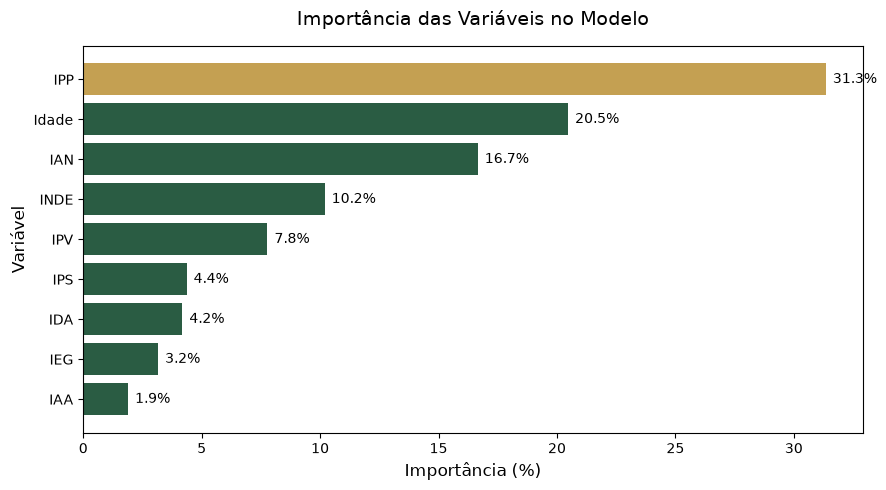

In [18]:
# =========================================================
# Gráfico 1 — Importância das variáveis
# =========================================================

fi_plot = fi.copy()

fi_plot['Variavel'] = (
    fi_plot['Variavel']
    .str.replace(
        'num__',
        '',
        regex=False
    )
)

fi_plot = (
    fi_plot
    .sort_values(
        'Importancia',
        ascending=True
    )
)

cores_barras = [
    COR_DESTAQUE
    if variavel == fi_plot.iloc[-1]['Variavel']
    else COR_PRIMARIA
    for variavel in fi_plot['Variavel']
]

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    fi_plot['Variavel'],
    fi_plot['Importancia'] * 100,
    color=cores_barras
)

ax.set_title(
    'Importância das Variáveis no Modelo',
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    'Importância (%)',
    fontsize=12
)

ax.set_ylabel(
    'Variável',
    fontsize=12
)

for i, valor in enumerate(
    fi_plot['Importancia'] * 100
):
    ax.text(
        valor + 0.3,
        i,
        f'{valor:.1f}%',
        va='center'
    )

plt.tight_layout()
plt.show()


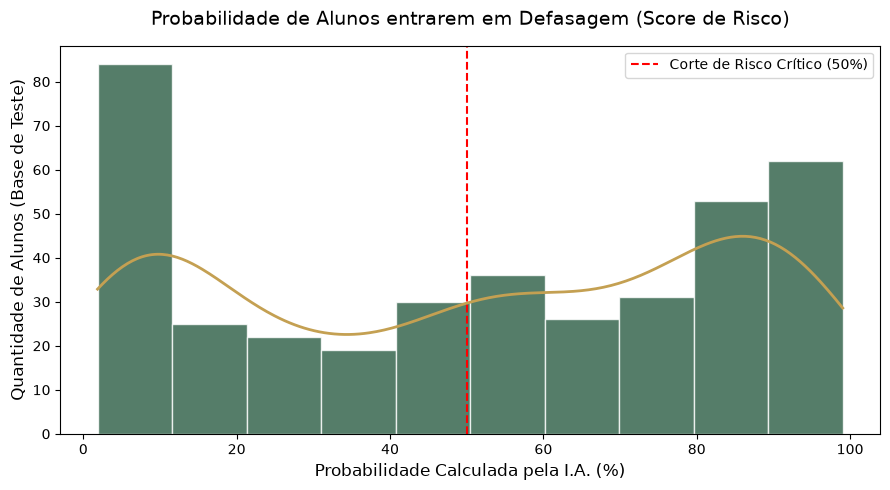

In [19]:
# =========================================================
# Gráfico 2 — Distribuição das probabilidades
# =========================================================

scores = probabilidades * 100

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.hist(
    scores,
    bins=10,
    color=COR_PRIMARIA,
    alpha=0.80,
    edgecolor='white'
)

if len(np.unique(scores)) > 1:
    kde = gaussian_kde(scores)
    x_kde = np.linspace(
        scores.min(),
        scores.max(),
        300
    )

    densidade = kde(x_kde)

    largura_bin = (
        scores.max() - scores.min()
    ) / 10

    densidade_escala = (
        densidade
        * len(scores)
        * largura_bin
    )

    ax.plot(
        x_kde,
        densidade_escala,
        color=COR_DESTAQUE,
        linewidth=2
    )

ax.axvline(
    50,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Corte de Risco Crítico (50%)'
)

ax.set_title(
    'Probabilidade de Alunos entrarem em Defasagem '
    '(Score de Risco)',
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    'Probabilidade Calculada pela I.A. (%)',
    fontsize=12
)

ax.set_ylabel(
    'Quantidade de Alunos (Base de Teste)',
    fontsize=12
)

ax.legend()

plt.tight_layout()
plt.show()


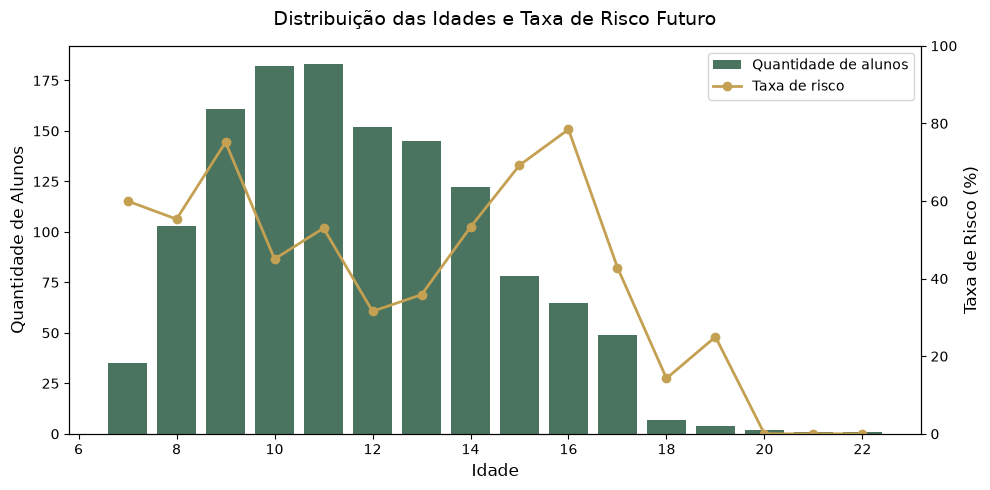

In [20]:
# =========================================================
# Gráfico 3 — Distribuição das idades e taxa de risco
# =========================================================

fig, ax_quantidade = plt.subplots(
    figsize=(10, 5)
)

ax_quantidade.bar(
    analise_idade['Idade'],
    analise_idade['Quantidade'],
    color=COR_PRIMARIA,
    alpha=0.85,
    label='Quantidade de alunos'
)

ax_quantidade.set_xlabel(
    'Idade',
    fontsize=12
)

ax_quantidade.set_ylabel(
    'Quantidade de Alunos',
    fontsize=12
)

ax_risco = ax_quantidade.twinx()

ax_risco.plot(
    analise_idade['Idade'],
    analise_idade['Taxa_Risco'],
    color=COR_DESTAQUE,
    marker='o',
    linewidth=2,
    label='Taxa de risco'
)

ax_risco.set_ylabel(
    'Taxa de Risco (%)',
    fontsize=12
)

ax_risco.set_ylim(
    0,
    100
)

ax_quantidade.set_title(
    'Distribuição das Idades e Taxa de Risco Futuro',
    fontsize=14,
    pad=15
)

linhas_1, labels_1 = (
    ax_quantidade
    .get_legend_handles_labels()
)

linhas_2, labels_2 = (
    ax_risco
    .get_legend_handles_labels()
)

ax_quantidade.legend(
    linhas_1 + linhas_2,
    labels_1 + labels_2,
    loc='upper right'
)

plt.tight_layout()
plt.show()
